In [ ]:
# ============================================================
# MOLEDO RANDOM FOREST TEMPORAL CON ID y SUBBAGING
#Autor: Hernan Garcia
#Fecha: 1/05/2026
#Fecha Ajuste: 1/05/2026
# ============================================================

In [1]:
# ============================================================
# PASO 0 — LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

In [2]:
# -------------------------------------------------------
# 1. Cargar los datos
# -------------------------------------------------------
# Ruta de tu archivo CSV (ajústala a tu disco)

BASEFINALAGRUPADA = pd.read_csv(r'C:\Users\garci\OneDrive\Programacion\01.Data\BASEFINALAGRUPADA.csv',
                               sep=';',
                               engine='python'
                               )

In [3]:
# ============================================================
# PASO 1 — BASE
# ============================================================

df = BASEFINALAGRUPADA.copy()
df.columns = df.columns.str.strip()

In [4]:
# ============================================================
# PASO 2 — AJUSTE DE VARIABLES (LOG)
# ============================================================

cat_vars = [
    "NUMERO CONTRATO",
    "ESTADO CONTRATO",
    "TIPO DE CONTRATO",
    "MODALIDAD DE CONTRATACION",
    "JUSTIFICACION DEL CONTRATO",
    "NIT_NOMBRE_CONTRATANTE",
    "DEPARTAMENTO ENTIDAD CONTRATANTE",
    "SECTOR ECONOMICO ENTIDAD CONTRATANTE",
    "ID_NOMBRE_CONTRATISTA",
    "TIPO DE EMPRESA CONTRATISTA",
    "DEPARTAMENTO CONTRATISTA"
]

dummy_vars = [
    "MULTA",
    "OBLIGACIONES AMBIENTALES",
    "OBLIGACIONES POST CONSUMO",
    "OBLIGACIONES POSCONFLICTO",
    "DESTINO GASTO",
    "ORDEN ENTIDAD",
    "AÑO DE ELECCIONES",
    "ELECCIONES PRESIDENCIALES",
    "ELECCIONES DE CONGRESO",
    "ELECCIONES MUNICIPALES"
]

cont_vars = [
    "AÑO FIRMA CONTRATO",
    "AÑO INICIO CONTRATO",
    "AÑO FINAL DEL CONTRATO",
    "SECUESTROS",
    "FINANCIERA",
    "POBLACION EN REINCORPORACION ELN",
    "POBLACION EN REINCORPORACION FARC",
    "POBLACION EN REINCORPORACION PARAMILITARES",
    "POBLACION EN REINCORPORACION OTROS",
    "COMBATE Y/O CONTACTO ARMADO FARC",
    "COMBATE Y/O CONTACTO ARMADO ELN",
    "COMBATE Y/O CONTACTO ARMADO PARAMILITAR",
    "COMBATE Y/O CONTACTO ARMADO OTROS",
    "POBLACION NINI",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO COMPETENCIAS CIUDADANAS",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO COMUNICACION ESCRITA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO ESCRITURA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO INLGES",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO LECTURA CRITICA",
    "PUNTAJE PROMEDIO EN PRUEBAS SABER PRO RAZONAMIENTO CUANTITATIVO",
    "DELITOS ELECTORALES",
    "NRO CORRESPONSALES PROPIOS",
    "NRO CORRESPONSALES TERCERIZADOS",
    "NRO CORRESPONSALES ACTIVOS",
    "NRO CORRESPONSALES",
    "NRO GIROS ENVIADOS ",
    "MONTO GIROS ENVIADOS ",
    "NRO GIROS RECIBIDOS",
    "NRO PAGOS",
    "NRO RETIROS",
    "NRO TRANSFERENCIAS",
    "NRO TOTAL ",
    "NRO CTA AHORRO HASTA 1 SMMLV",
    "NRO CTA AHORRO > 1 SMMLV HASTA 3 SMMLV",
    "NRO CTA AHORRO> 3 SMMLV HASTA 5 SMMLV",
    "NRO CTA AHORRO ACTIVAS",
    "NRO CTA AHORRO MUJERES",
    "NRO CTA AHORRO HOMBRES",
    "NRO TOTAL CTA AHORROS",
    "NRO CTA AHORRO ELECTRONICAS ACTIVAS",
    "NRO CTA AHORRO ELECTRONICAS MUJERES",
    "NRO CTA AHORRO ELECTRONICAS HOMBRES",
    "NRO TOTAL CTA AHORROS ELECTRONICAS ",
    "NRO CREDITO CONSUMO MUJERES",
    "MONTO CREDITO CONSUMO MUJERES",
    "NRO CREDITO CONSUMO HOMBRES",
    "MONTO CREDITO CONSUMO  HOMBRES",
    "NRO TOTAL CREDITO CONSUMO",
    "MONTO TOTAL CREDITO CONSUMO",
    "NRO CRED CONS BAJO MONTO MUJERES",
    "NRO CRED CONS BAJO MONTO HOMBRES",
    "NRO TOTAL CRED CONS BAJO MONTO",
    "NRO CREDITO VIVIENDA MUJERES",
    "MONTO CREDITO VIVIENDA MUJERES",
    "NRO CREDITO VIVIENDA HOMBRES",
    "MONTO CREDITO VIVIENDA HOMBRES",
    "NRO TOTAL CREDITO VIVIENDA",
    "NRO MICROCREDITO HASTA 1 SMMLV",
    "MONTO MICROCREDITO HASTA 1 SMMLV",
    "NRO MICROCREDITO > 1 SMMLV HASTA 2 SMMLV",
    "NRO MICROCREDITO> 2 SMMLV HASTA 3 SMMLV",
    "NRO MICROCREDITO> 3 SMMLV HASTA 4 SMMLV",
    "NRO MICROCREDITO> 4 SMMLV HASTA 10 SMMLV",
    "NRO MICROCREDITO> 10SMMLV HASTA 25SMMLV",
    "NRO MICROCREDITO MUJERES",
    "NRO MICROCREDITO HOMBRES",
    "NRO TOTAL MICROCREDITO ",
    "NRO PROD DEPOSITO NIVEL NACIONAL",
    "MONTO PROD DEPOSITO NIVEL NACIONAL"
    
]

index_vars = [
    "IDH",
    "PROMEDIO INDICE IICA",
    "TASA DE ALFABETIZACION",
    "INDICE EFICIENCIA FISCAL",
    "INDICE EFICACIA TOTAL ",
    "INDICE EFICIENCIA TOTAL",
    "INDICE REQUISITOS LEGALES",
    "CAPACIDAD ADMINISTRATIVA"
]

log_vars = [
    "VALOR CONTRATO",
    "PIB AGRICULTURA Y GANADERÍA",
    "PIB EXPLOTACIÓN DE MINAS Y CANTERAS",
    "PIB INDUSTRIAS MANUFACTURERAS",
    "PIB SUMINISTRO DE ELECTRICIDAD, GAS ETC",
    "PIB CONSTRUCCION",
    "PIB COMERCIO AL POR MAYOR Y AL POR MENOR",
    "PIB INFORMACIÓN Y COMUNICACIONES",
    "PIB ACTIVIDADES FINANCIERAS",
    "PIB ACTIVIDADES INMOBILIARIAS",
    "PIB ACTIVIDADES PROFESIONALES",
    "PIB ADMINISTRACIÓN PÚBLICA Y DEFENSA",
    "PIB ACTIVIDADES ARTÍSTICAS",
    "HOMICIDIOS",
    "HURTOS PERSONAS",
    "VIOLENCIA INTRAFAMILIAR",
    "HURTO A VEHICULOS",
    "DELITOS SEXUALES",
    "DELITOS MEDIO AMBIENTE",
    "HURTO A COMERCIOS",
    "RESIDENCIAS",
    "INCAUTACIONES DE ARMAS",
    "DESPLAZADOS PERCAPITA",
    "DESPLAZADOS NUMERO DE CASOS",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS EN UNIVERSIDAD PUBLICA",
    "NUMERO TOTAL DE DOCENTES UNIVERSITARIOS EN UNIVERSIDAD PRIVADA",
    "NUMERO DE MATRICULADOS A EDUCACION SUPERIOR",
    "NUMERO DE ADMITIDOS A EDUCACION SUPERIOR",
    "NUMERO DE INSCRITOS EN UNIVERSIDADES",
    "NUMERO EMPLEADOS ADMINISTRATIVOS",
    "NUMERO DE GRADUADOS",
    "HECTAREAS SEMBRADAS DE COCAINA",
    "DESMANTELAMIENTO DE LABORATORIOS",
    "HECTAREAS ERRADICADAS",
    "ENCAUTACIONES DE DROGA EN GRAMOS",
    "NRO DEPOSITOS",
    "MONTO DEPOSITOS",
    "MONTO GIROS RECIBIDOS",
    "MONTO PAGOS",
    "MONTO RETIROS",
    "MONTO TRANSFERENCIAS",
    "MONTO TOTAL",
    "SALDO CTA AHORRO HASTA 1 SMMLV",
    "SALDO CTA AHORRO> 1 SMMLV HASTA 3 SMMLV",
    "SALDO CTA AHORRO> 3 SMMLV HASTA 5 SMMLV",
    "SALDO CTA AHORRO ACTIVAS",
    "SALDO CTA AHORRO MUJERES",
    "SALDO CTA AHORRO HOMBRES",
    "SALDO TOTAL CTA AHORROS",
    "SALDO CTA AHORRO ELECTRONICAS ACTIVAS",
    "SALDO CTA AHORRO ELECTRONICAS MUJERES",
    "SALDO CTA AHORRO ELECTRONICAS HOMBRES",
    "SALDO TOTAL CTA AHORROS ELECTRONICAS ",
    "MONTO CRED CONS BAJO MONTO MUJERES",
    "MONTO CRED CONS BAJO MONTO HOMBRES",
    "MONTO TOTAL CRED CONS BAJO MONTO",
    "MONTO TOTAL CREDITO VIVIENDA",
    "MONTO MICROCREDITO> 1SMMLV HASTA 2SMMLV",
    "MONTO MICROCREDITO> 2SMMLV HASTA 3SMMLV",
    "MONTO MICROCREDITO> 3SMMLV HASTA 4SMMLV",
    "MONTO MICROCREDITO> 4SMMLV HASTA 10SMML",
    "MONTO MICROCREDI> 10SMMLV HASTA 25SMMLV",
    "MONTO MICROCREDITO MUJERES",
    "MONTO MICROCREDITO HOMBRES",
    "MONTO TOTAL MICROCREDITO"
    
]

# --- LOG ---
for col in log_vars:
    if col in df.columns:

        df[col] = (
            df[col]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(" ", "", regex=False)
        )

        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].clip(lower=0)
        df[col] = np.log1p(df[col])


# --- CONTINUAS ---
for col in cont_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# --- DUMMIES ---
for col in dummy_vars:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        df[col] = df[col].astype(int)


# --- CATEGÓRICAS ---
for col in cat_vars:
    if col in df.columns:
        df[col] = df[col].astype(str)


# --- ÍNDICES ---
for col in index_vars:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
print("\nTransformación log aplicada.")


Transformación log aplicada.


In [5]:
# ============================================================
# PASO 2 — VARIABLES CLAVE
# ============================================================

target_var = "MULTA"
year_var = "AÑO FIRMA CONTRATO"

In [7]:
# ============================================================
# PASO 4 — PLAZO
# ============================================================

if "AÑO INICIO CONTRATO" in df.columns and "AÑO FINAL DEL CONTRATO" in df.columns:

    plazo = (
        df["AÑO FINAL DEL CONTRATO"] - df["AÑO INICIO CONTRATO"]
    ).clip(lower=0)

    df = df.assign(PLAZO_CONTRATO=plazo)

    df = df.drop(columns=[
        "AÑO INICIO CONTRATO",
        "AÑO FINAL DEL CONTRATO"
    ])

# 🔥 DESFRAGMENTAR (CLAVE)
df = df.copy()

In [8]:
# ============================================================
# PASO 5 — SPLIT TEMPORAL
# ============================================================

cut_year = 2020

train_df = df[df[year_var] < cut_year]
test_df  = df[df[year_var] >= cut_year]

In [9]:
# ============================================================
# PASO 6 — X / y
# ============================================================

X_train = train_df.drop(columns=[target_var])
y_train = train_df[target_var]

X_test = test_df.drop(columns=[target_var])
y_test = test_df[target_var]

X_train = X_train.drop(columns=[year_var], errors="ignore")
X_test  = X_test.drop(columns=[year_var], errors="ignore")


In [10]:
# ============================================================
# PASO 7 — ELIMINAR COLUMNAS VACÍAS
# ============================================================

cols_all_nan = X_train.columns[X_train.isna().all()]

X_train = X_train.drop(columns=cols_all_nan)
X_test  = X_test.drop(columns=cols_all_nan)

In [11]:
# ============================================================
# PASO 8 — DEFINIR COLUMNAS
# ============================================================

categorical_cols = [col for col in cat_vars if col in X_train.columns]
numeric_cols = [
    col for col in (cont_vars + log_vars + index_vars + dummy_vars)
    if col in X_train.columns
]


In [12]:
# ============================================================
# PASO 9 — REDUCIR CARDINALIDAD
# ============================================================

for col in categorical_cols:

    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

    top = X_train[col].value_counts().nlargest(10).index

    X_train[col] = X_train[col].where(X_train[col].isin(top), "OTROS")
    X_test[col] = X_test[col].where(X_test[col].isin(top), "OTROS")

In [13]:
# ============================================================
# PASO 10 — PREPROCESAMIENTO
# ============================================================

preprocessor = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True 
        ))
    ]), categorical_cols),

    ("num", SimpleImputer(strategy="median"), numeric_cols)
], sparse_threshold=1.0)

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

In [14]:
# ============================================================
# PASO 11 — SUBBAGGING
# ============================================================

from sklearn.utils import resample
from scipy.sparse import vstack  # 🔥 IMPORTANTE

n_models = 5

models = []
probs_list = []

# máscaras correctas
mask_0 = (y_train == 0).values
mask_1 = (y_train == 1).values

X_train_0 = X_train_enc[mask_0]
X_train_1 = X_train_enc[mask_1]

y_train_0 = y_train[mask_0]
y_train_1 = y_train[mask_1]

for i in range(n_models):

    # undersampling
    X_0_sample, y_0_sample = resample(
        X_train_0,
        y_train_0,
        replace=False,
        n_samples=len(y_train_1),
        random_state=42 + i
    )

    # 🔥 AQUÍ EL CAMBIO IMPORTANTE
    X_bal = vstack([X_0_sample, X_train_1])
    y_bal = np.concatenate([y_0_sample, y_train_1])

    model_sub = RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42 + i,
        n_jobs=-1
    )

    model_sub.fit(X_bal, y_bal)

    probs = model_sub.predict_proba(X_test_enc)[:, 1]
    probs_list.append(probs)

# promedio final
test_probs = np.mean(probs_list, axis=0)

print("\nSubbagging ejecutado correctamente.")


Subbagging ejecutado correctamente.


In [15]:
# ============================================================
# PASO 12 — PROMEDIO DE PROBABILIDADES
# ============================================================
models = []
probs_list = []

for i in range(n_models):

    ...

    model_sub.fit(X_bal, y_bal)

    models.append(model_sub)

    probs = model_sub.predict_proba(X_test_enc)[:, 1]
    probs_list.append(probs)

In [16]:
# ============================================================
# PASO 13 — SELECCIÓN ROBUSTA DE THRESHOLD 🔥
# ============================================================

thresholds = np.linspace(0.001, 0.2, 50)

results = []

for t in thresholds:

    y_pred_temp = (test_probs > t).astype(int)

    precision = precision_score(y_test, y_pred_temp, zero_division=0)
    recall = recall_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(
    results,
    columns=["threshold", "precision", "recall", "f1"]
)

# 🔥 SELECCIÓN ROBUSTA
filtered = results_df[results_df["precision"] > 0.01]

if len(filtered) > 0:
    best = filtered.loc[filtered["recall"].idxmax()]
    print("\nThreshold seleccionado (precision > 1%)")

else:
    print("\n⚠️ No hay thresholds con precision > 1%")
    print("👉 Usando mejor F1")

    best = results_df.loc[results_df["f1"].idxmax()]

print(best)

best_threshold = best["threshold"]



⚠️ No hay thresholds con precision > 1%
👉 Usando mejor F1
threshold    0.200000
precision    0.001445
recall       1.000000
f1           0.002885
Name: 49, dtype: float64


In [17]:
# ============================================================
# PASO 14 — PREDICCIÓN FINAL
# ============================================================
y_pred = (test_probs > best_threshold).astype(int)

print("\nDistribución de predicciones:")
print(pd.Series(y_pred).value_counts())


Distribución de predicciones:
0    263654
1    102446
Name: count, dtype: int64


In [18]:
# ============================================================
# PASO 15 — MÉTRICAS
# ============================================================

print("\nRESULTADOS FINALES:")

print("AUC:", roc_auc_score(y_test, test_probs))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


RESULTADOS FINALES:
AUC: 0.9625379443501082
Precision: 0.0014446635300548582
Recall: 1.0
F1: 0.0028851589761584497


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    roc_curve
)

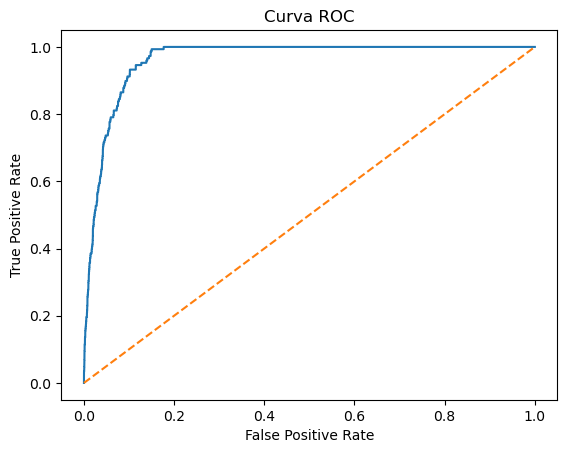

In [25]:
# ============================================================
# PASO 16 — CURVA ROC
# ============================================================

fpr, tpr, _ = roc_curve(y_test, test_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

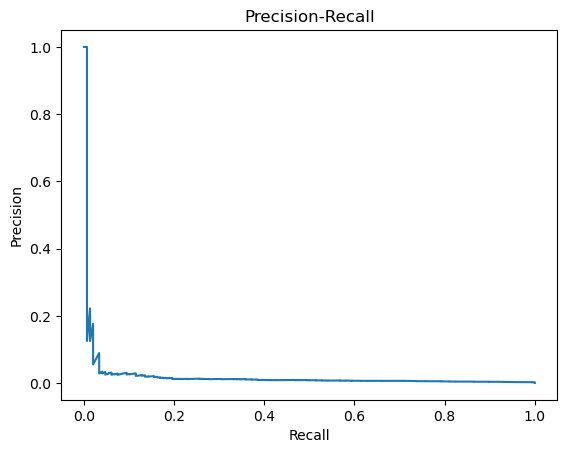

In [26]:
# ============================================================
# PASO 17 — CURVA PRECISION-RECALL
# ============================================================
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probs)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.title("Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [27]:
# ============================================================
# PASO 18 — IMPORTANCIA DE VARIABLES SUBBAGGING 
# ============================================================

feature_names = preprocessor.get_feature_names_out()

importances_list = []

for m in models:
    importances_list.append(m.feature_importances_)

# promedio
mean_importances = np.mean(importances_list, axis=0)

feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": mean_importances
}).sort_values(by="Importancia", ascending=False)

print("\nTop 10 variables más importantes (Subbagging):")
print(feature_importance.head(10))


Top 10 variables más importantes (Subbagging):
                                         Variable  Importancia
110              cat__DEPARTAMENTO CONTRATISTA_34     0.120387
214             num__MONTO TOTAL CREDITO VIVIENDA     0.037563
158                           num__VALOR CONTRATO     0.034052
199                     num__MONTO TRANSFERENCIAS     0.033162
219  num__MONTO MICROCREDI> 10SMMLV HASTA 25SMMLV     0.030605
221               num__MONTO MICROCREDITO HOMBRES     0.030581
218  num__MONTO MICROCREDITO> 4SMMLV HASTA 10SMML     0.030064
204                 num__SALDO CTA AHORRO ACTIVAS     0.025465
111               cat__DEPARTAMENTO CONTRATISTA_5     0.024123
200                              num__MONTO TOTAL     0.023581


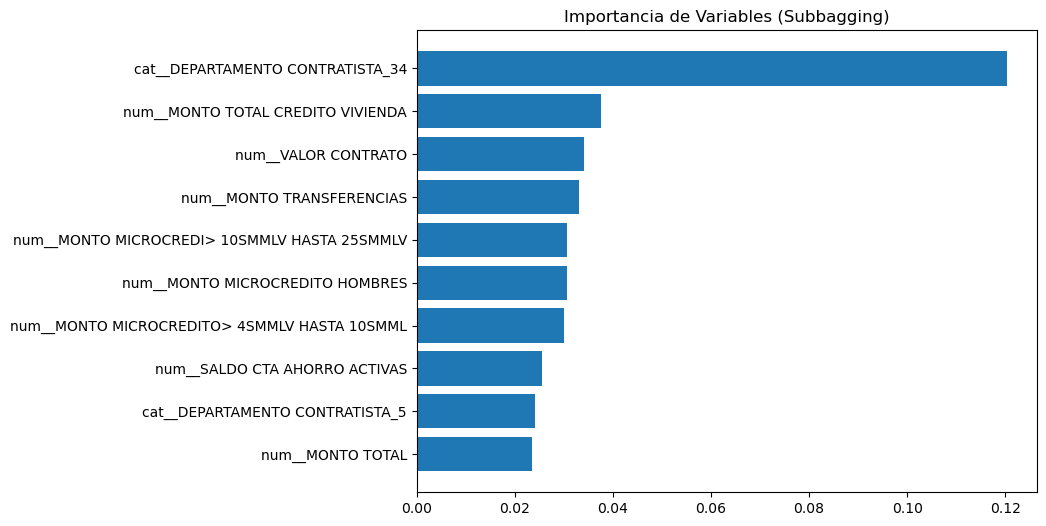

In [28]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Variable"], top_features["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables (Subbagging)")
plt.show()

In [30]:
# ============================================================
# PASO 20 — ALERTAS
# ============================================================

alertas = pd.DataFrame({
    "Probabilidad": test_probs
})

alertas["Score"] = alertas["Probabilidad"] * 100

alertas["Nivel"] = pd.cut(
    alertas["Score"],
    bins=[0, 10, 30, 60, 100],
    labels=["Bajo", "Medio", "Alto", "Crítico"]
)

print("\nDistribución de alertas:")
print(alertas["Nivel"].value_counts())


Distribución de alertas:
Nivel
Bajo       173872
Medio      135207
Alto        53902
Crítico      3119
Name: count, dtype: int64


In [31]:
# ============================================================
# PASO 21 — IMPACTO ECONÓMICO
# ============================================================

if "VALOR CONTRATO" in X_test.columns:

    alertas["Valor_Contrato"] = pd.to_numeric(
        X_test["VALOR CONTRATO"], errors="coerce"
    )

    alertas["Perdida_Esperada"] = (
        alertas["Probabilidad"] * alertas["Valor_Contrato"]
    )

    print("\nTop contratos con mayor riesgo económico:")
    print(alertas.sort_values(
        by="Perdida_Esperada",
        ascending=False
    ).head(10))


Top contratos con mayor riesgo económico:
        Probabilidad      Score    Nivel  Valor_Contrato  Perdida_Esperada
257624      0.731038  73.103810  Crítico       27.074152         19.792236
129311      0.713157  71.315702  Crítico       27.694625         19.750616
140417      0.713004  71.300363  Crítico       26.941245         19.209206
1735        0.708726  70.872606  Crítico       27.001877         19.136934
31          0.682849  68.284923  Crítico       27.885297         19.041453
228713      0.761589  76.158864  Crítico       24.889931         18.955889
249736      0.722773  72.277278  Crítico       26.061097         18.836251
349133      0.701303  70.130346  Crítico       26.786999         18.785815
3           0.665754  66.575431  Crítico       27.695632         18.438486
306888      0.723899  72.389918  Crítico       25.448479         18.422133
